# Linear Autoencoder on Correlation Matrices
In this notebook we train a linear autoencoder (no non-linear activations) on full correlation matrices, compress them into a latent space, reconstruct them, and evaluate reconstruction quality across different latent dimensions.

In [1]:
from pathlib import Path
import random
import warnings
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

## Step 1: Load Data
Load correlation matrices from a `.pt` file and optionally select a matrix range `[MATRIX_START, MATRIX_END)`.

In [2]:
MY_FILE_NAME = 'corr_windows_tensor_data_00_20_w724_s10.pt'

if 'google.colab' in sys.modules:
    print('Ambiente rilevato: Google Colab')
    IS_COLAB = True
else:
    print('Ambiente rilevato: Locale (PC)')
    IS_COLAB = False

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    processed_dir = Path('/content/drive/MyDrive/dataset_tesi')
else:
    project_root = Path.cwd().resolve().parent
    processed_dir = project_root / 'data' / 'processed'

selected_file = processed_dir / MY_FILE_NAME

if not selected_file.exists():
    raise FileNotFoundError(
        f"Errore: Il file '{MY_FILE_NAME}' non e stato trovato in: {processed_dir.absolute()}"
    )

print(f'File selezionato: {selected_file.name}')

# Select the matrix range to use: [MATRIX_START, MATRIX_END)
MATRIX_START = 49  # number or None
MATRIX_END = None  # number or None, Example: 500 to use only the first 500 matrices
print(f'Matrix range: [{MATRIX_START}, {MATRIX_END})')

Ambiente rilevato: Google Colab
Mounted at /content/drive
File selezionato: corr_windows_tensor_data_00_20_w724_s10.pt
Matrix range: [49, None)


In [3]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta


corr_tensor, meta = load_corr_payload(selected_file)

orig_n = corr_tensor.shape[0]
start_idx = 0 if MATRIX_START is None else int(MATRIX_START)
end_idx = orig_n if MATRIX_END is None else int(MATRIX_END)

if not (0 <= start_idx < end_idx <= orig_n):
    raise ValueError(f'Invalid matrix range [{start_idx}, {end_idx}) for dataset size {orig_n}')

corr_tensor = corr_tensor[start_idx:end_idx]
if 'window_ranges' in meta and len(meta['window_ranges']) == orig_n:
    meta['window_ranges'] = meta['window_ranges'][start_idx:end_idx]

print(f'corr_tensor shape (selected range): {tuple(corr_tensor.shape)}')
print(f'using matrices: [{start_idx}, {end_idx}) out of {orig_n}')
print(f'dtype: {corr_tensor.dtype}')

corr_tensor shape (selected range): (412, 362, 362)
using matrices: [49, 461) out of 461
dtype: torch.float32


## Step 2: Prepare Matrices and Train/Validation Split
Use full correlation matrices as input. For training, each matrix is flattened to a vector of size `N x N`.

In [4]:
SEED = 42
VAL_FRACTION = 0.2

corr_np = corr_tensor.numpy().astype(np.float32)
n_matrices, n_assets, _ = corr_np.shape
n_features = n_assets * n_assets

X_flat = torch.from_numpy(corr_np.reshape(n_matrices, n_features))

rng = np.random.default_rng(SEED)
indices = np.arange(n_matrices)
rng.shuffle(indices)

n_val = max(1, int(n_matrices * VAL_FRACTION))
val_idx = indices[:n_val]
train_idx = indices[n_val:]

if len(train_idx) == 0:
    raise ValueError('Training split is empty. Reduce VAL_FRACTION or use more matrices.')

x_train = X_flat[train_idx]
x_val = X_flat[val_idx]

print(f'Number of matrices: {n_matrices}')
print(f'Matrix shape: ({n_assets}, {n_assets})')
print(f'Flattened input size: {n_features}')
print(f'Train size: {len(train_idx)} | Val size: {len(val_idx)}')

Number of matrices: 412
Matrix shape: (362, 362)
Flattened input size: 131044
Train size: 330 | Val size: 82


## Step 3: Define a Linear Autoencoder
The encoder and decoder are pure linear layers (no activation functions).

In [5]:
class LinearAutoencoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int):
        super().__init__()
        self.encoder = nn.Linear(input_dim, latent_dim)
        self.decoder = nn.Linear(latent_dim, input_dim)

    def forward(self, x: torch.Tensor):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

## Step 4: Training and Evaluation Utilities
Train the model, reconstruct matrices, and compute reconstruction errors.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_linear_ae(
    x_train_tensor: torch.Tensor,
    x_val_tensor: torch.Tensor,
    latent_dim: int,
    epochs: int = 80,
    batch_size: int = 64,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    seed: int = 42,
):
    set_seed(seed)

    model = LinearAutoencoder(input_dim=x_train_tensor.shape[1], latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    train_loader = DataLoader(TensorDataset(x_train_tensor), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(x_val_tensor), batch_size=batch_size, shuffle=False)

    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0
        for (xb,) in train_loader:
            xb = xb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, xb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * xb.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                pred = model(xb)
                loss = criterion(pred, xb)
                val_loss_sum += loss.item() * xb.size(0)

        val_loss = val_loss_sum / len(val_loader.dataset)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f'Epoch {epoch + 1:>3}/{epochs} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}')

    return model, history


def reconstruct_matrices(model: nn.Module, x_tensor: torch.Tensor, n_assets: int, batch_size: int = 4):
    model.eval()
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False)
    outputs = []

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            outputs.append(pred)

    recon_flat = np.concatenate(outputs, axis=0)
    recon = recon_flat.reshape(-1, n_assets, n_assets).astype(np.float32)

    # Enforce correlation-matrix structure after reconstruction.
    recon = 0.5 * (recon + np.transpose(recon, (0, 2, 1)))
    diag_idx = np.arange(n_assets)
    recon[:, diag_idx, diag_idx] = 1.0

    return recon


def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix,
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats

Device: cuda


## Step 5: Train One Configuration and Reconstruct Matrices
Train one linear AE configuration, reconstruct all matrices, and inspect training losses.

Epoch   1/1000 | train_loss=0.188762 | val_loss=0.173747
Epoch   2/1000 | train_loss=0.176563 | val_loss=0.171449
Epoch   3/1000 | train_loss=0.174002 | val_loss=0.169363
Epoch   4/1000 | train_loss=0.172909 | val_loss=0.168020
Epoch   5/1000 | train_loss=0.172414 | val_loss=0.167821
Epoch   6/1000 | train_loss=0.172179 | val_loss=0.167633
Epoch   7/1000 | train_loss=0.172015 | val_loss=0.167497
Epoch   8/1000 | train_loss=0.171901 | val_loss=0.167380
Epoch   9/1000 | train_loss=0.171796 | val_loss=0.167287
Epoch  10/1000 | train_loss=0.171705 | val_loss=0.167196
Epoch  11/1000 | train_loss=0.171617 | val_loss=0.167109
Epoch  12/1000 | train_loss=0.171530 | val_loss=0.167024
Epoch  13/1000 | train_loss=0.171445 | val_loss=0.166954
Epoch  14/1000 | train_loss=0.171365 | val_loss=0.166867
Epoch  15/1000 | train_loss=0.171280 | val_loss=0.166776
Epoch  16/1000 | train_loss=0.171191 | val_loss=0.166697
Epoch  17/1000 | train_loss=0.171111 | val_loss=0.166617
Epoch  18/1000 | train_loss=0.1

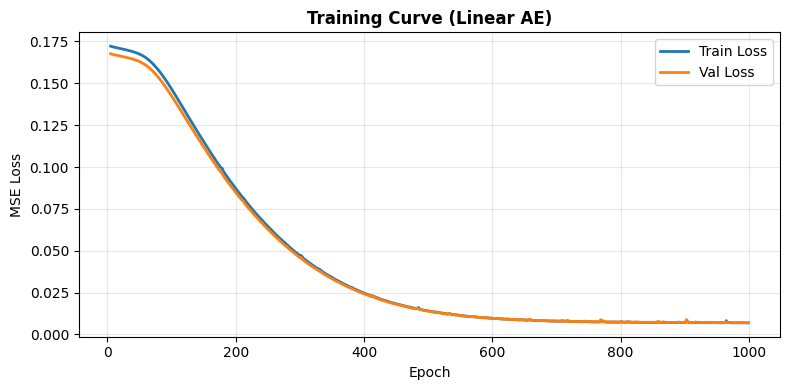

In [12]:
LATENT_DIM = 20
EPOCHS = 1000
BATCH_SIZE = 32
LR = 1e-5
WEIGHT_DECAY = 0.0

model, history = train_linear_ae(
    x_train_tensor=x_train,
    x_val_tensor=x_val,
    latent_dim=LATENT_DIM,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    seed=SEED,
)

orig_corr = corr_np
recon_corr = reconstruct_matrices(model, X_flat, n_assets=n_assets)

print(f'Original tensor shape: {orig_corr.shape}')
print(f'Reconstructed tensor shape: {recon_corr.shape}')
print(f'Latent dimension: {LATENT_DIM}')

fig, ax = plt.subplots(figsize=(8, 4))
epochs_to_plot = list(range(5, EPOCHS))
ax.plot(epochs_to_plot, history['train_loss'][5:], label='Train Loss', linewidth=2)
ax.plot(epochs_to_plot, history['val_loss'][5:], label='Val Loss', linewidth=2)
ax.set_title('Training Curve (Linear AE)', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Step 6: Matrix-Level Reconstruction Visualization
Show the same reconstruction plots used in the PCA notebook: clustered heatmaps and standard heatmaps (original, reconstructed, error).

Sample index: 200
MSE: 0.004567 | MAE: 0.052868 | Frobenius: 24.465126
Error range - Min: -0.313434 | Max: 0.415545


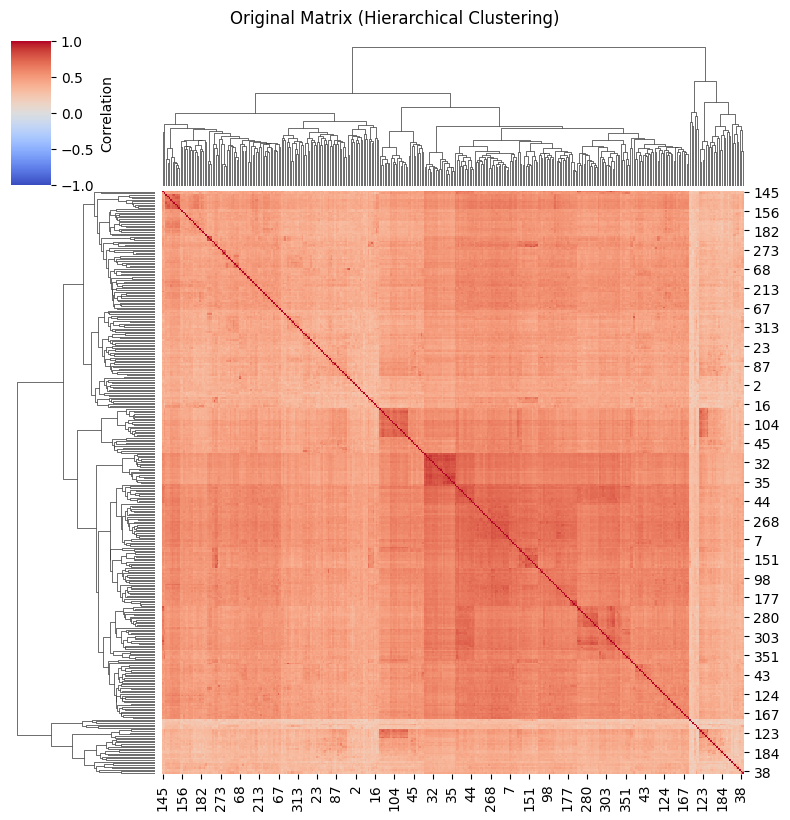

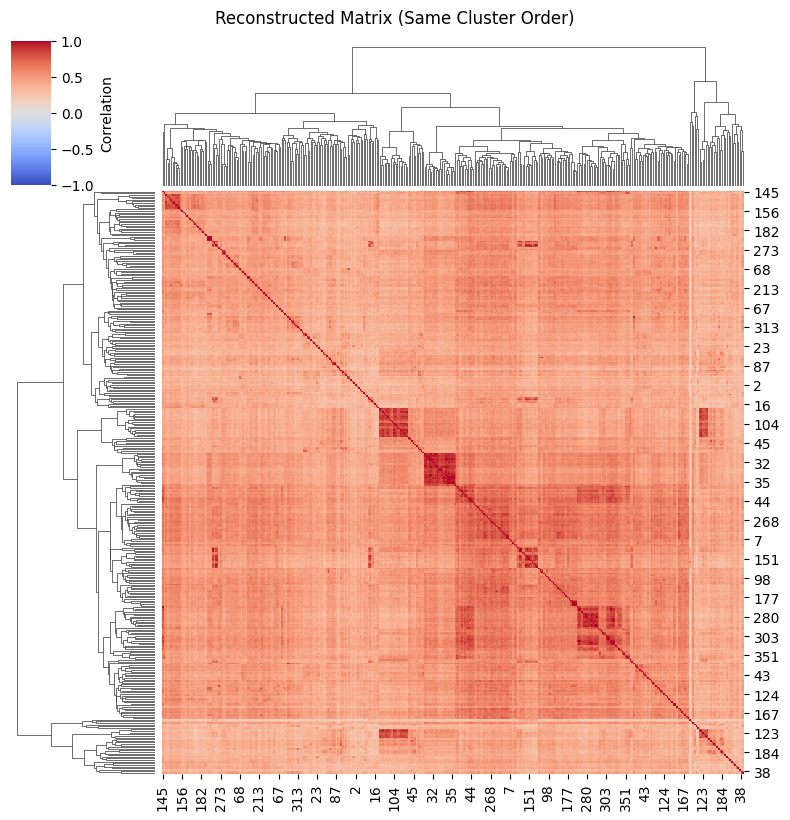

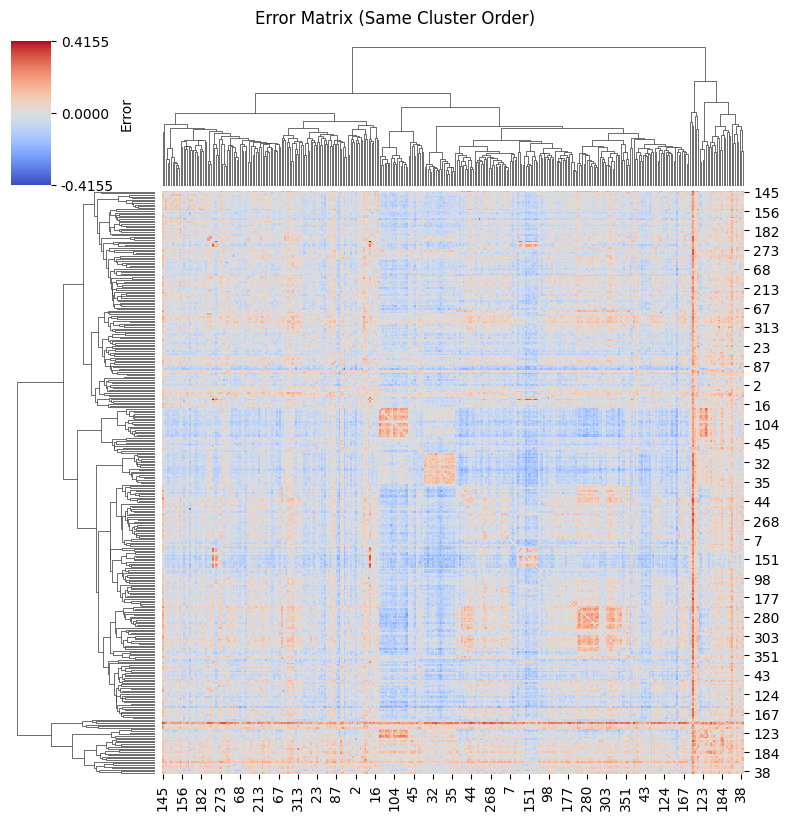

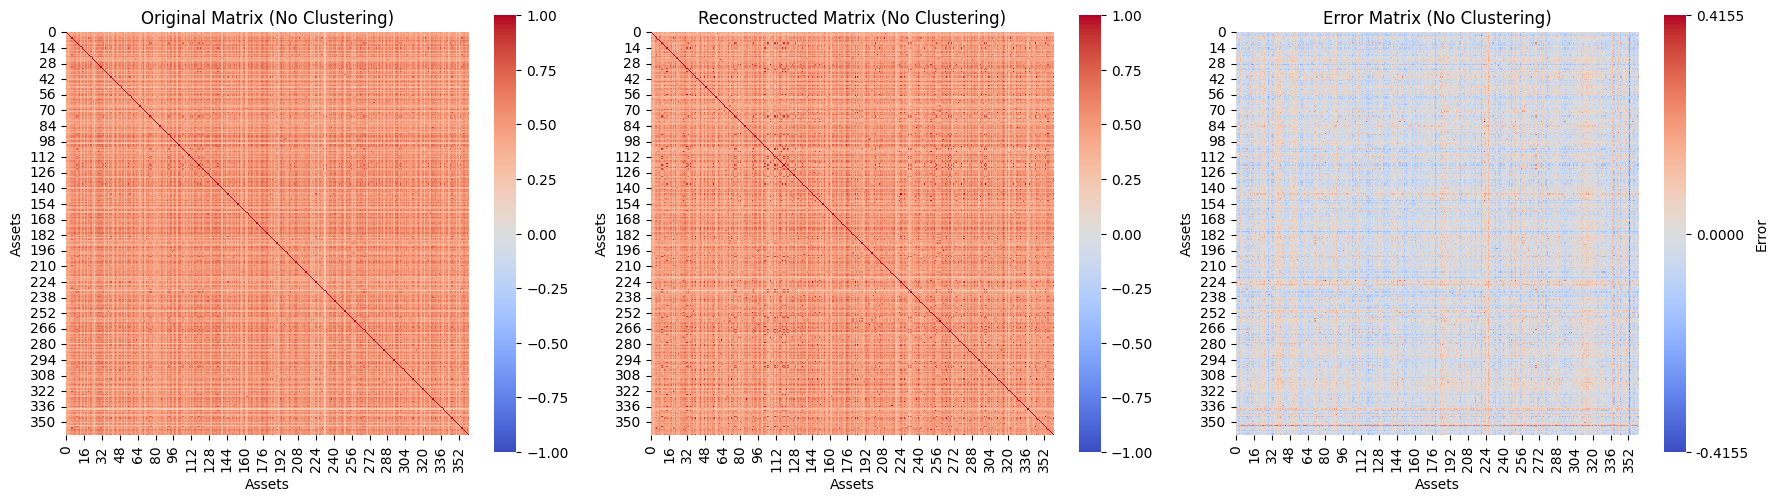

In [13]:
sample_idx = 200

if not (0 <= sample_idx < orig_corr.shape[0]):
    raise ValueError(f'sample_idx must be in [0, {orig_corr.shape[0] - 1}]')

orig_mat = orig_corr[sample_idx]
recon_mat = recon_corr[sample_idx]
err_mat = recon_mat - orig_mat

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'Sample index: {sample_idx}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

shared_cmap = 'coolwarm'
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

cluster_true = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
cluster_true.figure.suptitle('Original Matrix (Hierarchical Clustering)', y=1.02)
plt.show()

row_linkage = cluster_true.dendrogram_row.linkage
col_linkage = cluster_true.dendrogram_col.linkage

cluster_recon = sns.clustermap(
    recon_mat,
    row_linkage=row_linkage,
    col_linkage=col_linkage,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
cluster_recon.figure.suptitle('Reconstructed Matrix (Same Cluster Order)', y=1.02)
plt.show()

cluster_err = sns.clustermap(
    err_mat,
    row_linkage=row_linkage,
    col_linkage=col_linkage,
    center=0,
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Error'},
)
cbar_cluster = cluster_err.ax_heatmap.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])
cluster_err.figure.suptitle('Error Matrix (Same Cluster Order)', y=1.02)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(
    err_mat,
    ax=axes[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes[2].set_title('Error Matrix (No Clustering)')

cbar_std = hm.collections[0].colorbar
cbar_std.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_std.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')

plt.tight_layout()
plt.show()

## Step 7: Reconstruction Error Statistics
Compute error statistics on the validation set (MSE, MAE, Frobenius norm).

In [14]:
# Compute error statistics on validation set only
orig_corr_val = corr_np[val_idx]
recon_corr_val = recon_corr[val_idx]

errors_df, errors_stats = reconstruction_errors(orig_corr_val, recon_corr_val)

print('Reconstruction error statistics (Validation Set):')
display(errors_stats)

Reconstruction error statistics (Validation Set):


,mean,std,min,median,max
MSE,0.006471,0.002018,0.004126,0.005640,0.011376
MAE,0.062464,0.009159,0.050331,0.058967,0.083064
Frobenius,28.807316,4.286887,23.253437,27.185848,38.610329


## Step 8: Sweep Different Latent Dimensions
Train multiple linear AE configurations and compare reconstruction quality.

In [17]:
candidate_latents = [1, 2, 3, 5, 10, 20]
candidate_latents = [d for d in candidate_latents if d <= n_features]

SWEEP_EPOCHS = 100
SWEEP_BATCH_SIZE = 32
SWEEP_LR = 1e-3

rows = []
for latent_dim in candidate_latents:
    print(f'\nTraining latent_dim={latent_dim}')
    model_sweep, _ = train_linear_ae(
        x_train_tensor=x_train,
        x_val_tensor=x_val,
        latent_dim=latent_dim,
        epochs=SWEEP_EPOCHS,
        batch_size=SWEEP_BATCH_SIZE,
        lr=SWEEP_LR,
        weight_decay=0.0,
        seed=SEED,
    )

    recon_sweep = reconstruct_matrices(model_sweep, X_flat, n_assets=n_assets)
    _, stats_sweep = reconstruction_errors(orig_corr, recon_sweep)

    rows.append({
        'latent_dim': latent_dim,
        'MSE_mean': float(stats_sweep.loc['MSE', 'mean']),
        'MAE_mean': float(stats_sweep.loc['MAE', 'mean']),
        'Frobenius_mean': float(stats_sweep.loc['Frobenius', 'mean']),
    })

sweep_df = pd.DataFrame(rows).sort_values('latent_dim').reset_index(drop=True)

display(sweep_df)


Training latent_dim=1
Epoch   1/100 | train_loss=238.527947 | val_loss=159.512288
Epoch   2/100 | train_loss=57.852241 | val_loss=60.507314
Epoch   3/100 | train_loss=24.376912 | val_loss=12.735666
Epoch   4/100 | train_loss=8.862575 | val_loss=3.310977
Epoch   5/100 | train_loss=3.273957 | val_loss=1.935278
Epoch   6/100 | train_loss=1.502941 | val_loss=1.407820
Epoch   7/100 | train_loss=0.916780 | val_loss=0.834018
Epoch   8/100 | train_loss=0.637065 | val_loss=0.482488
Epoch   9/100 | train_loss=0.535648 | val_loss=0.522419
Epoch  10/100 | train_loss=0.496055 | val_loss=0.477949
Epoch  11/100 | train_loss=0.475148 | val_loss=0.469522
Epoch  12/100 | train_loss=0.467106 | val_loss=0.457439
Epoch  13/100 | train_loss=0.460681 | val_loss=0.453619
Epoch  14/100 | train_loss=0.455557 | val_loss=0.449108
Epoch  15/100 | train_loss=0.451426 | val_loss=0.445255
Epoch  16/100 | train_loss=0.447638 | val_loss=0.441384
Epoch  17/100 | train_loss=0.443887 | val_loss=0.437612
Epoch  18/100 | t

,latent_dim,MSE_mean,MAE_mean,Frobenius_mean
0,1,0.116247,0.271910,121.630913
1,2,0.074125,0.217267,95.868057
2,3,0.063546,0.202156,88.058365
3,5,0.057221,0.192989,82.895554
4,10,0.048954,0.179710,75.768387
5,20,0.043524,0.168673,71.180847


## Step 9: Visualize Results
Reconstruction errors vs latent dimension (MSE, MAE, Frobenius)

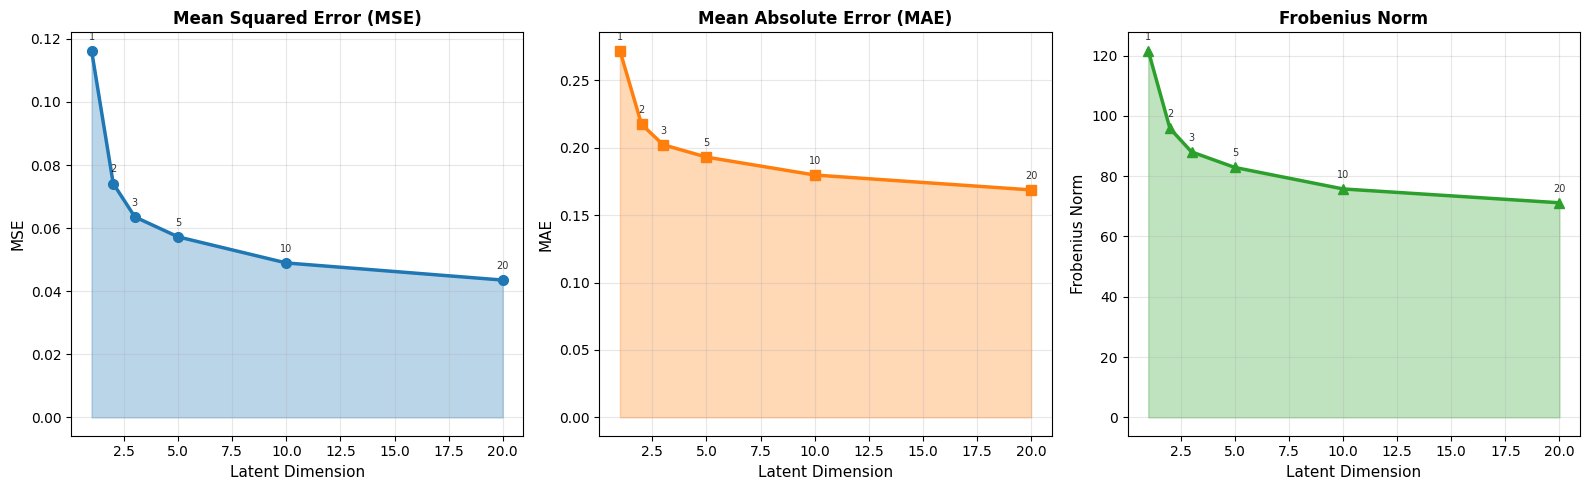

In [18]:
fig2, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(sweep_df['latent_dim'], sweep_df['MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes[0].fill_between(sweep_df['latent_dim'], sweep_df['MSE_mean'], alpha=0.3, color='#1f77b4')
for latent_dim, val in zip(sweep_df['latent_dim'], sweep_df['MSE_mean']):
    axes[0].annotate(f'{int(latent_dim)}', xy=(latent_dim, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes[0].set_title('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Latent Dimension', fontsize=11)
axes[0].set_ylabel('MSE', fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_df['latent_dim'], sweep_df['MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes[1].fill_between(sweep_df['latent_dim'], sweep_df['MAE_mean'], alpha=0.3, color='#ff7f0e')
for latent_dim, val in zip(sweep_df['latent_dim'], sweep_df['MAE_mean']):
    axes[1].annotate(f'{int(latent_dim)}', xy=(latent_dim, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes[1].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Latent Dimension', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(sweep_df['latent_dim'], sweep_df['Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes[2].fill_between(sweep_df['latent_dim'], sweep_df['Frobenius_mean'], alpha=0.3, color='#2ca02c')
for latent_dim, val in zip(sweep_df['latent_dim'], sweep_df['Frobenius_mean']):
    axes[2].annotate(f'{int(latent_dim)}', xy=(latent_dim, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes[2].set_title('Frobenius Norm', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Latent Dimension', fontsize=11)
axes[2].set_ylabel('Frobenius Norm', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()